In [38]:
import os
import pandas as pd
import numpy as np

In [39]:
class Buoy:
    """
    Class for processing NOAA buoy data from various file formats and years.
    Handles different header formats, year representations, and column variations.
    """
    
    def __init__(self, directory):
        self.directory = directory
        self.headers = [
            "YYYY (year)", "MM (month)", "DD (day)", "hh (hour)", "mm (minute)", 
            "WDIR (degT)", "WSPD (m/s)", "GST (m/s)", "WVHT (m)", "DPD (sec)", 
            "APD (sec)", "MWD (deg)", "PRES (hPa)", "ATMP (degC)", "WTMP (degC)", 
            "DEWP (degC)", "VIS (nmi)", "TIDE (ft)"
        ]
        self.data = None
        self.dataframes = []
    
    def _extract_year_from_filename(self, filename):
        filename_year = None
        if 'h' in filename and filename.endswith('.txt'):
            try:
                year_part = filename.split('h')[1].split('.')[0]
                if len(year_part) == 4 and year_part.isdigit():
                    filename_year = int(year_part)
            except:
                pass
        return filename_year
    
    def _determine_file_format(self, header_lines, filename):
        if len(header_lines) < 1:
            return 'unknown', 1
            
        first_line = header_lines[0]
        second_line = header_lines[1] if len(header_lines) > 1 else ""
        
        if '#YY' in first_line and '#yr' in second_line:
            return 'double_with_header', 2
        elif ('YY' in first_line) and ('yr' not in second_line):
            return 'double', 1
        elif 'YYYY' in first_line and 'TIDE' not in first_line:
            return 'four', 1
        elif 'YYYY' in first_line and 'TIDE' in first_line and 'mm' not in first_line:
            return 'four_tide', 1
        elif 'YYYY' in first_line and 'mm' in first_line:
            if any(unit in second_line for unit in ['yr', 'mo', 'degT']):
                return 'full', 2
            else:
                return 'full', 1
        else:
            return 'unknown', 1
    
    def _process_single_file(self, filepath, filename):
        filename_year = self._extract_year_from_filename(filename)
        
        with open(filepath, 'r') as file:
            header_lines = []
            for i in range(5):
                line = file.readline().strip()
                if line:
                    header_lines.append(line)
                if len(header_lines) >= 2:
                    break
        
        year_format, skiprows = self._determine_file_format(header_lines, filename)
        print(f"Processing {filename}: Format '{year_format}', skipping {skiprows} rows")
        
        df = pd.read_csv(filepath, sep='\s+', skiprows=skiprows, header=None, on_bad_lines='skip')
        
        if df.empty:
            print(f"Skipping {filename}: Empty data")
            return None
            
        first_year_in_file = df[0].iloc[0] if len(df) > 0 else None
        
        if first_year_in_file is not None:
            if len(str(int(first_year_in_file))) <= 2:
                df[0] = df[0].apply(lambda x: 1900 + int(x) if int(x) >= 80 else 2000 + int(x))
            elif filename_year is not None and abs(int(first_year_in_file) - filename_year) > 100:
                print(f"Correcting year in {filename}: from {first_year_in_file} to {filename_year}")
                df[0] = filename_year
        
        first_line = header_lines[0] if header_lines else ""
        
        if 'mm' not in first_line:
            df.insert(4, 'mm', 0)
        
        pres_col_index = 12
        if 'PRES' not in first_line and 'BAR' in first_line:
            pass
        elif 'PRES' not in first_line and 'BAR' not in first_line:
            df.insert(pres_col_index, 'PRES', None)
            
        if 'TIDE' not in first_line:
            df['TIDE'] = None
        
        if 'WD' in first_line and 'WDIR' not in first_line:
            col_index = 5
            df.rename(columns={df.columns[col_index]: 'WDIR'}, inplace=True)
        
        if df.shape[1] > len(self.headers):
            df = df.iloc[:, :len(self.headers)]
        elif df.shape[1] < len(self.headers):
            for _ in range(len(self.headers) - df.shape[1]):
                df[len(df.columns)] = None
        
        df.columns = self.headers
        
        df["YYYY (year)"] = df["YYYY (year)"].apply(
            lambda x: int(x) if isinstance(x, (int, float)) and 1984 <= int(x) <= 2025 else filename_year
        )
        
        print(f"Processed {filename} with {len(df)} rows, year range: {df['YYYY (year)'].min()}-{df['YYYY (year)'].max()}")
        return df
    
    def process_files(self):
        files = sorted([f for f in os.listdir(self.directory) if f.endswith('.txt')])
        
        for filename in files:
            filepath = os.path.join(self.directory, filename)
            
            try:
                df = self._process_single_file(filepath, filename)
                if df is not None:
                    self.dataframes.append(df)
            except Exception as e:
                print(f"Error processing {filename}: {str(e)}")
                continue
        
        if self.dataframes:
            self.data = pd.concat(self.dataframes, ignore_index=True)
            
            self.data["YYYY (year)"] = pd.to_numeric(self.data["YYYY (year)"], 
                                                   errors='coerce').fillna(2000).astype(int)
            
            self.data = self.data.sort_values(
                by=["YYYY (year)", "MM (month)", "DD (day)", "hh (hour)", "mm (minute)"]
            )
            
            self.data = self.data.reset_index(drop=True)
            
            print("\nCombined DataFrame:")
            print(f"Total rows: {len(self.data)}")
            print(f"Year range: {self.data['YYYY (year)'].min()} - {self.data['YYYY (year)'].max()}")
            return self.data
        else:
            print("No valid data found in the directory")
            return None
    
    def save_data(self, output_path):
        if self.data is not None:
            self.data.to_csv(output_path, index=False)
            print(f"Data saved to {output_path}")
        else:
            print("No data to save. Run process_files() first.")
    
    def extrapolate_to_turbine_height(self, target_height=150, reference_height=10, alpha=None):
        df = self.data.copy()
        
        if alpha is None:
            alpha = 0.14
        
        height_ratio = target_height / reference_height
        df['WSPD_150m'] = df['WSPD (m/s)'] * (height_ratio ** alpha)
        df['GST_150m'] = df['GST (m/s)'] * (height_ratio ** alpha)
        
        return df

    def calculate_wind_shear(self, heights=[10, 50, 100, 150], base_height=10):
        df = self.data.copy()
        
        df['stability'] = 'neutral'
        
        conditions = [
            ((df['hh (hour)'] >= 10) & (df['hh (hour)'] <= 16)),
            ((df['hh (hour)'] >= 22) | (df['hh (hour)'] <= 4))
        ]
        choices = ['unstable', 'stable']
        df['stability'] = np.select(conditions, choices, default='neutral')
        
        stability_alphas = {'stable': 0.20, 'neutral': 0.14, 'unstable': 0.10}
        df['alpha'] = df['stability'].map(stability_alphas)
        
        for height in heights:
            if height != base_height:
                height_ratio = height / base_height
                df[f'WSPD_{height}m'] = df['WSPD (m/s)'] * (height_ratio ** df['alpha'])
                df[f'GST_{height}m'] = df['GST (m/s)'] * (height_ratio ** df['alpha'])
        
        top_height = 215
        bottom_height = 85
        
        df['WSPD_top'] = df['WSPD (m/s)'] * ((top_height/base_height) ** df['alpha'])
        df['WSPD_bottom'] = df['WSPD (m/s)'] * ((bottom_height/base_height) ** df['alpha'])
        df['rotor_shear'] = (df['WSPD_top'] - df['WSPD_bottom']) / 130
        
        return df

    def identify_extreme_events(self, wspd_threshold=25, gust_threshold=35, shear_threshold=0.15):
        df = self.calculate_wind_shear()
        
        extreme_conditions = (
            (df['WSPD_150m'] >= wspd_threshold) |
            (df['GST_150m'] >= gust_threshold) |
            (df['rotor_shear'] >= shear_threshold)
        )
        
        extreme_events = df[extreme_conditions].copy()
        
        extreme_events['gust_factor'] = extreme_events.apply(
            lambda row: row['GST_150m'] / row['WSPD_150m'] if row['WSPD_150m'] != 0 else np.nan,
            axis=1
        )
        
        extreme_events = extreme_events.sort_values(by=['GST_150m', 'rotor_shear'], ascending=False)
        
        return extreme_events

    def simulate_extreme_gust(self, turbulence_intensity=0.15, duration_minutes=10, 
                             return_period_years=50, timestep_seconds=1):
        wind_stats = self.data['WSPD (m/s)'].describe()
        ve50 = wind_stats['mean'] + 5 * wind_stats['std']
        
        D = 130
        Lambda = 42
        
        sigma = turbulence_intensity * wind_stats['mean']
        
        if return_period_years == 1:
            gust_magnitude = 4.8 * sigma
        else:
            gust_magnitude = 6.4 * sigma
        
        n_steps = int(duration_minutes * 60 / timestep_seconds)
        time_series = pd.DataFrame({
            'time_sec': np.arange(0, duration_minutes * 60, timestep_seconds),
            'u_ref': wind_stats['mean']
        })
        
        t_gust = 10.5 * D / Lambda
        
        def eog_function(t, t_gust, u_ref, gust_magnitude):
            t_norm = t / t_gust
            if 0 <= t_norm <= 1:
                return u_ref - 0.37 * gust_magnitude * np.sin(3 * np.pi * t_norm) * (1 - np.cos(2 * np.pi * t_norm))
            else:
                return u_ref
        
        center = duration_minutes * 30
        time_series['wind_speed'] = time_series.apply(
            lambda row: eog_function(
                row['time_sec'] - center, 
                t_gust, 
                row['u_ref'], 
                gust_magnitude
            ), 
            axis=1
        )
        
        time_series['wind_speed_top'] = time_series['wind_speed'] * 1.15
        time_series['wind_speed_bottom'] = time_series['wind_speed'] * 0.85
        
        return time_series

    def extreme_event_statistics(self, extreme_events):
        extreme_events['event_group'] = (
            (~extreme_events.index.to_series().diff().eq(1))
            .cumsum()
        )
        
        dir_sectors = pd.cut(extreme_events['WDIR (degT)'], 
                             bins=[0, 45, 90, 135, 180, 225, 270, 315, 360],
                             labels=['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])
        
        dir_stats = extreme_events.groupby(dir_sectors)['GST_150m'].agg(['max', 'mean', 'count'])
        
        durations = extreme_events.groupby('event_group').size()
        
        return {
            'direction_stats': dir_stats,
            'max_duration_hours': durations.max() / 6,
            'mean_duration_hours': durations.mean() / 6
        }

    def calculate_ve50(self, height=150):
        df = self.extrapolate_to_turbine_height(target_height=height)
        df['year'] = df['YYYY (year)']
        annual_max = df.groupby('year')['WSPD_150m'].max()
        
        from scipy import stats
        shape, loc, scale = stats.gumbel_r.fit(annual_max)
        
        p = 1 - 1/50
        ve50 = stats.gumbel_r.ppf(p, loc=loc, scale=scale)
        
        return ve50

Processing 44009h1984.txt: Format 'double', skipping 1 rows
Processed 44009h1984.txt with 8411 rows, year range: 1984-1984
Processing 44009h1985.txt: Format 'double', skipping 1 rows
Processed 44009h1985.txt with 7490 rows, year range: 1985-1985
Processing 44009h1986.txt: Format 'double', skipping 1 rows
Processed 44009h1986.txt with 5504 rows, year range: 1986-1986
Processing 44009h1987.txt: Format 'double', skipping 1 rows
Processed 44009h1987.txt with 8683 rows, year range: 1987-1987
Processing 44009h1988.txt: Format 'double', skipping 1 rows
Processed 44009h1988.txt with 6471 rows, year range: 1988-1988
Processing 44009h1989.txt: Format 'double', skipping 1 rows
Processed 44009h1989.txt with 8425 rows, year range: 1989-1989
Processing 44009h1990.txt: Format 'double', skipping 1 rows
Processed 44009h1990.txt with 8548 rows, year range: 1990-1990
Processing 44009h1991.txt: Format 'double', skipping 1 rows
Processed 44009h1991.txt with 8725 rows, year range: 1991-1991
Processing 44009

/var/folders/c9/zx22n7c1713_ck39lvd8nlx00000gn/T/ipykernel_16214/1009991179.py:130: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  self.data = pd.concat(self.dataframes, ignore_index=True)


Found 59228 extreme wind events


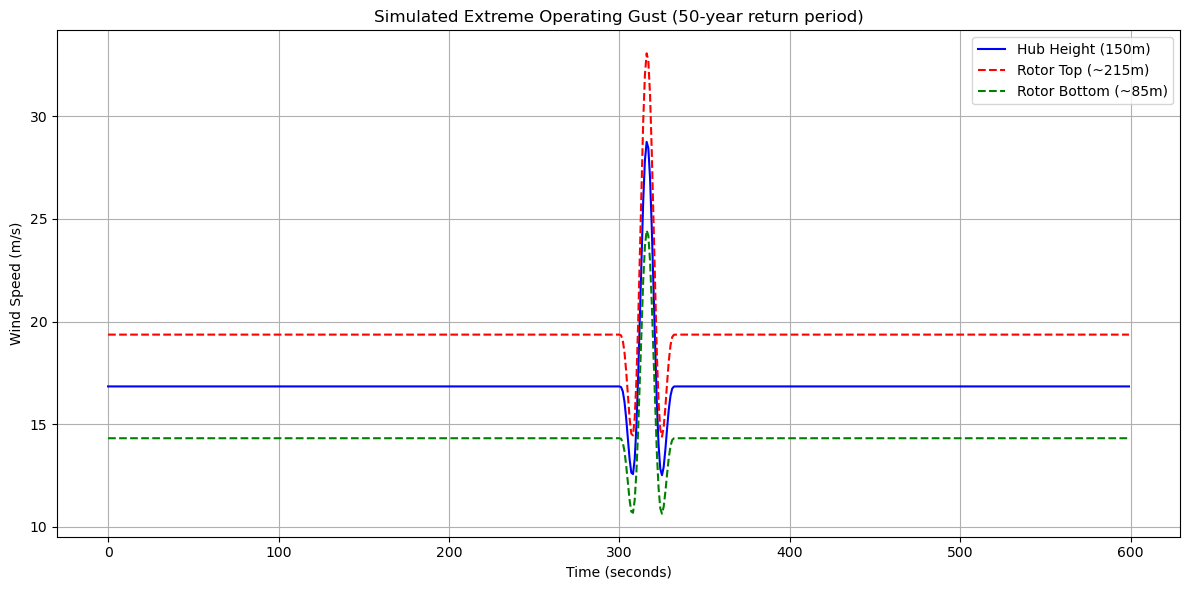

Extreme wind statistics for turbine design:
  max_wind_speed_150m: 170.16
  max_gust_150m: 170.16
  max_shear_across_rotor: 0.24
  max_gust_factor: 495.00


In [40]:
# Initialize the Buoy object with the directory path
buoy = Buoy('project_folder/Wind/Extreme wind shear and gust/NOAA Buoy data')

# Process all files
buoy.process_files()

# Extrapolate wind speeds to turbine height
turbine_data = buoy.extrapolate_to_turbine_height(target_height=150)

# Calculate detailed wind shear
shear_data = buoy.calculate_wind_shear()

# Identify extreme events in historical data
extreme_events = buoy.identify_extreme_events()
print(f"Found {len(extreme_events)} extreme wind events")

# Simulate an extreme operating gust scenario for turbine design
gust_simulation = buoy.simulate_extreme_gust(return_period_years=50)

# Plot the simulated extreme gust
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.plot(gust_simulation['time_sec'], gust_simulation['wind_speed'], 'b-', label='Hub Height (150m)')
plt.plot(gust_simulation['time_sec'], gust_simulation['wind_speed_top'], 'r--', label='Rotor Top (~215m)')
plt.plot(gust_simulation['time_sec'], gust_simulation['wind_speed_bottom'], 'g--', label='Rotor Bottom (~85m)')
plt.xlabel('Time (seconds)')
plt.ylabel('Wind Speed (m/s)')
plt.title('Simulated Extreme Operating Gust (50-year return period)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Calculate key statistics for wind farm design
extreme_stats = {
    'max_wind_speed_150m': shear_data['WSPD_150m'].max(),
    'max_gust_150m': shear_data['GST_150m'].max(),
    'max_shear_across_rotor': shear_data['rotor_shear'].max(),
    'max_gust_factor': extreme_events['gust_factor'].max() if len(extreme_events) > 0 else 0
}

print("Extreme wind statistics for turbine design:")
for key, value in extreme_stats.items():
    print(f"  {key}: {value:.2f}")